In [19]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import scipy.io as io
import sys
import numpy as np
from tqdm import tqdm
import gc

global_path = "/home/ids/edabier/HSU"
sys.path.append(f"{global_path}/SS-HSU_benchmark")
from src.utils import utils, losses, plots, extractor
from src.models import models, upsamplers, foundation_models as rsfm, unmixers as unmx

dev = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
torch.set_default_device(dev)
print(f"Using device: {dev}")

Using device: cuda:0


In [20]:
dataset = "urban"
data = io.loadmat(f"{global_path}/SS-HSU_benchmark/datasets/{dataset}.mat")
Y_flat = torch.tensor(data["Y"], dtype=torch.float)
A_flat = torch.tensor(data["A"], dtype=torch.float)
E_init = torch.tensor(data["E"], dtype=torch.float)

Y_init = utils.oneD_to_2d(Y_flat)
A_init = utils.oneD_to_2d(A_flat)
Y_init = Y_init.unsqueeze(0)
A_init = A_init.unsqueeze(0)
Y_init = utils.standardise(Y_init)

Y_init, A_init = rsfm.reshape_Y("DOFA", Y_init, 224, A_init)
Y_init = Y_init[0]
A_init = A_init[0]
B, c, H = E_init.shape[0], E_init.shape[1], Y_init.shape[-1]

wavelengths_path = f"{global_path}/SS-HSU_benchmark/datasets/{dataset}_wavelength.txt"
with open(wavelengths_path, "r") as file:
    lines = file.readlines()
    wavelengths = [float(line.strip()) for line in lines if line.strip()]

### CNNAEU

In [ ]:
# n_xp = 10
# mses, sads = [], []
# loader, _, _ = utils.create_dataloader(dataset, patch_size=None, dev=dev, path=global_path)

# for i in range(n_xp):
#     print(f"training {i+1}/{n_xp}")

#     model = models.CNNAEU(B, c)
#     model = models.init_decoder_weights(model, Y_init/Y_init.max(), c, kernel=11, use_sivm=False)

#     epochs, lr = 320, 0.0003
#     optimizer = torch.optim.RMSprop(model.parameters(), lr)

#     for _ in tqdm(range(epochs)):

#         for Y, _, _ in loader:
        
#             optimizer.zero_grad()
#             Y= utils.oneD_to_2d(Y)
#             Y = rsfm.reshape_Y("DOFA", Y, 224)
#             Y = Y.flatten(2)

#             E_hat, A_hat, Y_hat = model(Y)

#             loss = model.loss(E_hat, A_hat, Y, Y_hat)
#             loss.backward()
#             nn.utils.clip_grad_norm_(model.parameters(), max_norm=10, norm_type=1)
#             optimizer.step()
    
#     model.eval()
    
#     with torch.no_grad():
        
#         E_hat, A_hat, _ = model(Y)

#         if i < n_xp - 1:
#             sad, _, mse = plots.compute_metrics_and_plot(E_hat[0], utils.oneD_to_2d(A_hat), A_init, E_init, normalise_E=True, normalise_A=True, return_results=True, plot_E=False, plot_A=False)
#         else:
#             sad, _, mse = plots.compute_metrics_and_plot(E_hat[0], utils.oneD_to_2d(A_hat), A_init, E_init, normalise_E=True, normalise_A=True, return_results=True)

#         print(f"Current SAD = {format(sad, '.3f')}, NMSE = {format(mse, '.3f')}")
#         mses.append(mse)
#         sads.append(sad)

# print(f"Average SAD = {format(torch.mean(torch.tensor(sads)), '.4f')} ± {format(torch.std(torch.tensor(sads)), '.3f')}, NMSE = {format(torch.mean(torch.tensor(mses)), '.4f')} ± {format(torch.std(torch.tensor(mses)), '.3f')}")
# torch.save(A_hat, f"{global_path}/SOTA_results/CNNAEU/{dataset}_A.pt")
# torch.save(E_hat, f"{global_path}/SOTA_results/CNNAEU/{dataset}_E.pt")

### DeepTrans

In [ ]:
# n_xp = 10
# mses, sads = [], []
# loader, _, _ = utils.create_dataloader(dataset, patch_size=None, dev=dev, path=global_path)

# for i in range(n_xp):
#     print(f"training {i+1}/{n_xp}")

#     model = models.DeepTrans(B, c, H, patch_size=7, embed_dim=392)
#     model_dict = model.state_dict()
#     model_dict['decoder.0.weight'] = extractor.SiVM(Y_init/Y_init.max(), c).unsqueeze(-1).unsqueeze(-1)
#     model.load_state_dict(model_dict)

#     epochs, lr = 200, 0.0006
#     optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=3e-5)
#     scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=15, gamma=0.8)
#     apply_clamp_inst1 = unmx.Weight_constraint()

#     for _ in tqdm(range(epochs)):

#         for Y, _, _ in loader:
        
#             optimizer.zero_grad()
#             Y = Y/Y.max()
#             Y = rsfm.reshape_Y("DOFA", utils.oneD_to_2d(Y), H).flatten(2)

#             E_hat, A_hat, Y_hat = model(Y)

#             loss = model.loss(E_hat, A_hat, utils.oneD_to_2d(Y), Y_hat)
#             loss.backward()
#             nn.utils.clip_grad_norm_(model.parameters(), max_norm=10, norm_type=1)
#             optimizer.step()

#             with torch.no_grad():
#                 model.decoder.apply(apply_clamp_inst1)

#         scheduler.step()
#     model.eval()
    
#     with torch.no_grad():
        
#         E_hat, A_hat, _ = model(Y)

#         if i < n_xp - 1:
#             sad, _, mse = plots.compute_metrics_and_plot(E_hat[0], A_hat, A_init, E_init, normalise_E=True, normalise_A=True, return_results=True, plot_E=False, plot_A=False)
#         else:
#             sad, _, mse = plots.compute_metrics_and_plot(E_hat[0], A_hat, A_init, E_init, normalise_E=True, normalise_A=True, return_results=True)

#         print(f"Current SAD = {format(sad, '.3f')}, NMSE = {format(mse, '.3f')}")
#         mses.append(mse)
#         sads.append(sad)

# print(f"Average SAD = {format(torch.mean(torch.tensor(sads)), '.4f')} ± {format(torch.std(torch.tensor(sads)), '.3f')}, NMSE = {format(torch.mean(torch.tensor(mses)), '.4f')} ± {format(torch.std(torch.tensor(mses)), '.3f')}")
# torch.save(A_hat, f"{global_path}/SOTA_results/DeepTrans/{dataset}_A.pt")
# torch.save(E_hat, f"{global_path}/SOTA_results/DeepTrans/{dataset}_E.pt")

### UnDIP

training 1/10


100%|██████████| 3000/3000 [02:29<00:00, 20.09it/s]


Current SAD = 0.394, NMSE = 0.870
training 2/10


100%|██████████| 3000/3000 [02:28<00:00, 20.18it/s]


Current SAD = 0.394, NMSE = 0.857
training 3/10


...

Current SAD = 0.394, NMSE = 0.863
training 9/10


100%|██████████| 3000/3000 [02:29<00:00, 20.06it/s]


Current SAD = 0.394, NMSE = 0.867
training 10/10


100%|██████████| 3000/3000 [02:30<00:00, 19.91it/s]


Current SAD = 0.394, NMSE = 0.867
Average SAD = 0.3939 ± 0.000, NMSE = 0.8663 ± 0.004


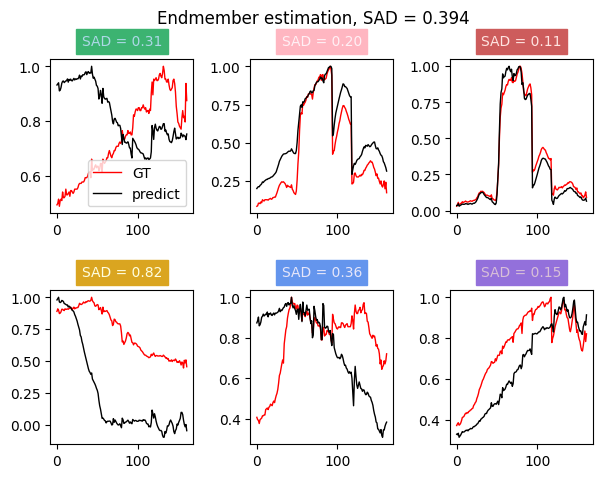

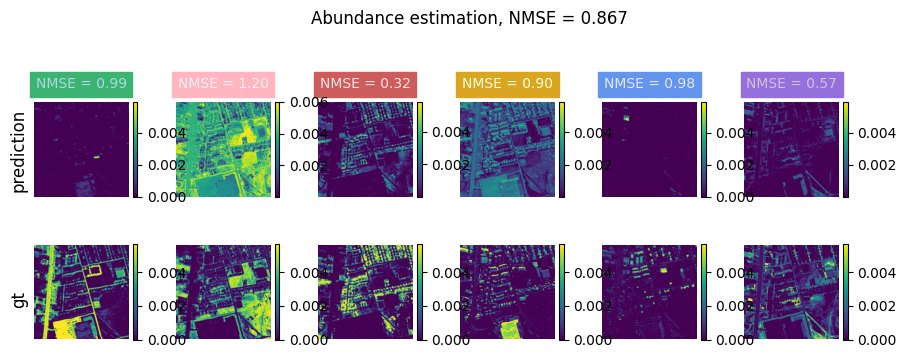

In [ ]:
n_xp = 10
mses, sads = [], []
loader, _, _ = utils.create_dataloader(dataset, patch_size=None, dev=dev, path=global_path)

for i in range(n_xp):
    print(f"training {i+1}/{n_xp}")

    model = models.UnDIP(B, c)

    epochs, lr = 3000, 0.001
    optimizer = torch.optim.Adam(model.parameters(), lr)

    for _ in tqdm(range(epochs)):

        for Y, _, _ in loader:
        
            optimizer.zero_grad()
            Y= utils.oneD_to_2d(Y)
            Y = rsfm.reshape_Y("DOFA", Y, 224)
            Y = Y.flatten(2)

            E_hat, A_hat, Y_hat = model(Y)

            loss = model.loss(E_hat, A_hat, Y, Y_hat)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=10, norm_type=1)
            optimizer.step()
    
    model.eval()
    
    with torch.no_grad():
        
        E_hat, A_hat, _ = model(Y)

        if i < n_xp - 1:
            sad, _, mse = plots.compute_metrics_and_plot(E_hat[0], utils.oneD_to_2d(A_hat), A_init, E_init, normalise_E=True, normalise_A=True, return_results=True, plot_E=False, plot_A=False)
        else:
            sad, _, mse = plots.compute_metrics_and_plot(E_hat[0], utils.oneD_to_2d(A_hat), A_init, E_init, normalise_E=True, normalise_A=True, return_results=True)

        print(f"Current SAD = {format(sad, '.3f')}, NMSE = {format(mse, '.3f')}")
        mses.append(mse)
        sads.append(sad)

print(f"Average SAD = {format(torch.mean(torch.tensor(sads)), '.4f')} ± {format(torch.std(torch.tensor(sads)), '.3f')}, NMSE = {format(torch.mean(torch.tensor(mses)), '.4f')} ± {format(torch.std(torch.tensor(mses)), '.3f')}")
torch.save(A_hat, f"{global_path}/SOTA_results/UnDIP/{dataset}_A.pt")
torch.save(E_hat, f"{global_path}/SOTA_results/UnDIP/{dataset}_E.pt")

### SiVM + FCLS

In [ ]:
# import time
# n_xp = 10
# mses, sads = [], []
# loader, _, _ = utils.create_dataloader(dataset, patch_size=None, dev=dev, path=global_path)
# times = []

# for i in range(n_xp):
#     print(f"unmixing {i+1}/{n_xp}")
#     start = time.time()

#     for Y, _, _ in loader:
    
#         optimizer.zero_grad()
#         Y = utils.oneD_to_2d(Y)
#         Y = rsfm.reshape_Y("DOFA", Y, 224)
#         E_hat = extractor.SiVM(Y[0], c)
#         A_hat = extractor.FCLS(Y[0].flatten(1), E_hat)

#     if i < n_xp - 1:
#         sad, _, mse = plots.compute_metrics_and_plot(E_hat, utils.oneD_to_2d(A_hat), A_init, E_init, normalise_E=True, normalise_A=True, return_results=True, plot_E=False, plot_A=False)
#     else:
#         sad, _, mse = plots.compute_metrics_and_plot(E_hat, utils.oneD_to_2d(A_hat), A_init, E_init, normalise_E=True, normalise_A=True, return_results=True)

#     print(f"Current SAD = {format(sad, '.3f')}, NMSE = {format(mse, '.3f')}")
#     mses.append(mse)
#     sads.append(sad)
#     times.append(time.time() - start)

# print(f"Average SAD = {format(torch.mean(torch.tensor(sads)), '.4f')} ± {format(torch.std(torch.tensor(sads)), '.3f')}, NMSE = {format(torch.mean(torch.tensor(mses)), '.4f')} ± {format(torch.std(torch.tensor(mses)), '.3f')}")
# torch.save(A_hat, f"{global_path}/SOTA_results/SiVM+FCLS/{dataset}_A.pt")
# torch.save(E_hat, f"{global_path}/SOTA_results/SiVM+FCLS/{dataset}_E.pt")
# np.mean(times)